In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget


RUN_ID = "20260309_004050__f7a1e02cd781__rpm1666p7__feed40p000__fs10000"
hash_id = params_hash = RUN_ID.split("__")[1] + "/"

# Hardcoded paths
PARAMS_PATH     = f"data/experiments/settings/{hash_id}/params.json"
EXPERIMENT_CSV  = f"data/experiments/{RUN_ID}/experiment_data.csv"
TRACE_CSV       = f"data/experiments/{RUN_ID}/path_trace.csv"

# Load params
with open(PARAMS_PATH, encoding="utf-8") as f:
    params = json.load(f)

# Load experiment data
df = pd.read_csv(EXPERIMENT_CSV)

# Load trace data
trace_df = pd.read_csv(TRACE_CSV)

print(f"Run-ID: {RUN_ID}")
print(f"Params hash: {hash_id} \n")


print(*df.columns.tolist(), sep="\n")
# print(trace_df.head())
print(json.dumps(params, indent= 4))

Run-ID: 20260309_004050__f7a1e02cd781__rpm1666p7__feed40p000__fs10000
Params hash: f7a1e02cd781/ 

time_s
x_x_m
x_y_m
u_x_N
u_y_N
fmill_x_N
fmill_y_N
tool_center_nominal_x_mm
tool_center_nominal_y_mm
tool_center_actual_x_mm
tool_center_actual_y_mm
tool_orientation
{
    "axial_cutting_depth_mm": 1.0,
    "dt": 0.0001,
    "feed_per_tooth_mm": 0.36000000000000004,
    "feed_speed_mm_s": 40.0,
    "feed_speed_path_mm_s": 40.0,
    "frequency_hz": 27.777777777777775,
    "linearized_model_npz": "linearized_operational_space_xyz.npz",
    "micro_mass_diag_kg": 80.0,
    "milling_path_csv": "data/paths/Workpiece_long_with_start_milling_path.csv",
    "omega_rad_s": -174.53292519943292,
    "path_offset_mm": null,
    "path_offset_side": "left",
    "period": 0.036000000000000004,
    "rev_per_s": 27.777777777777775,
    "rpm": 1666.6666666666665,
    "samples_per_period": 360,
    "spindle_spin": -1,
    "workpiece_pickle": "data/paths/Workpiece_long_with_start.pickle",
    "z_teeth": 4
}


   rev_idx  fx_avg_N  fy_avg_N  n_samples
0        0       0.0       0.0        361
1        1       0.0       0.0        359
2        2       0.0       0.0        361
3        3       0.0       0.0        359
4        4       0.0       0.0        361
-0.0
-6.265732014659641
613.861111111111


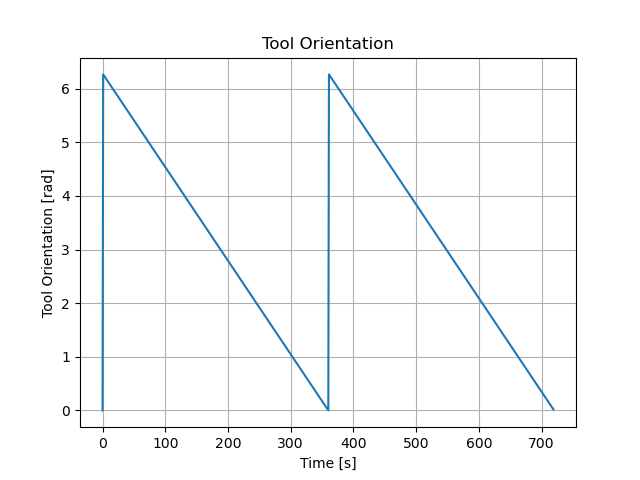

angle[0]           = -0.0
angle[359]         = -6.265732014659641
angle[360]         = -6.283185307179585
2π                 = 6.283185307179586
angle[0] mod 2π    = 0.0
angle[359] mod 2π  = 0.017453292519944874
angle[360] mod 2π  = 8.881784197001252e-16
Δθ mean            = -0.017453292519943292
samples / rev est  = -360.00000000000006


In [2]:
import numpy as np 

import numpy as np
import pandas as pd

def full_revolution_average(df: pd.DataFrame) -> pd.DataFrame:
    angle = df["tool_orientation"].to_numpy(dtype=float)

    rev_idx = np.floor((angle[0] - angle) / (2.0 * np.pi)).astype(int)

    return (
        df.assign(rev_idx=rev_idx)
        .groupby("rev_idx", as_index=False)
        .agg(
            fx_avg_N=("fmill_x_N", "mean"),
            fy_avg_N=("fmill_y_N", "mean"),
            n_samples=("rev_idx", "size"),
        )
    )

origin_rev = full_revolution_average(df)
print(origin_rev.head())

print(df["tool_orientation"][0])
print(df["tool_orientation"][360-1])

theta = df["tool_orientation"].to_numpy()
time = df["time_s"].to_numpy()

theta_rad = theta % (2*np.pi)
revolutions = np.absolute(theta / (2*np.pi))
print(max(revolutions))
end_idx = np.argmax(revolutions >= 2)

theta_first5 = theta[:end_idx]% (2*np.pi)
time_first5 = df["time_s"].to_numpy()[:end_idx]

# print(end_idx)

plt.figure()
plt.plot(theta_first5)

# plt.plot(theta)
# plt.plot()

plt.xlabel("Time [s]")
plt.ylabel("Tool Orientation [rad]")
plt.title("Tool Orientation")
plt.grid(True)
plt.show()


angle = df["tool_orientation"].to_numpy(dtype=float)

print("angle[0]           =", angle[0])
print("angle[359]         =", angle[359])
print("angle[360]         =", angle[360])
print("2π                 =", 2*np.pi)
print("angle[0] mod 2π    =", angle[0] % (2*np.pi))
print("angle[359] mod 2π  =", angle[359] % (2*np.pi))
print("angle[360] mod 2π  =", angle[360] % (2*np.pi))
print("Δθ mean            =", np.diff(angle).mean())
print("samples / rev est  =", (2*np.pi) / np.diff(angle).mean())

In [3]:
angle = df["tool_orientation"].to_numpy(dtype=float)
dtheta = angle - angle[0]
rev_float = dtheta / (2*np.pi)

for i in [0, 1, 2, 100, 200, 309, 310, 359, 360, 361]:
    print(i, angle[i], rev_float[i], np.floor(rev_float[i]))

0 -0.0 0.0 0.0
1 -0.017453292519943292 -0.0027777777777777775 -1.0
2 -0.034906585039886584 -0.005555555555555555 -1.0
100 -1.745329251994329 -0.27777777777777773 -1.0
200 -3.490658503988658 -0.5555555555555555 -1.0
309 -5.393067388662478 -0.8583333333333333 -1.0
310 -5.410520681182421 -0.8611111111111109 -1.0
359 -6.265732014659641 -0.997222222222222 -1.0
360 -6.283185307179585 -0.9999999999999999 -1.0
361 -6.300638599699528 -1.0027777777777775 -2.0


[-0.00000000e+00 -1.74532925e-02 -3.49065850e-02 ... -3.85696821e+03
 -3.85698566e+03 -3.85700311e+03]
{
    "axial_cutting_depth_mm": 1.0,
    "dt": 0.0001,
    "feed_per_tooth_mm": 0.36000000000000004,
    "feed_speed_mm_s": 40.0,
    "feed_speed_path_mm_s": 40.0,
    "frequency_hz": 27.777777777777775,
    "linearized_model_npz": "linearized_operational_space_xyz.npz",
    "micro_mass_diag_kg": 80.0,
    "milling_path_csv": "data/paths/Workpiece_long_with_start_milling_path.csv",
    "omega_rad_s": -174.53292519943292,
    "path_offset_mm": null,
    "path_offset_side": "left",
    "period": 0.036000000000000004,
    "rev_per_s": 27.777777777777775,
    "rpm": 1666.6666666666665,
    "samples_per_period": 360,
    "spindle_spin": -1,
    "workpiece_pickle": "data/paths/Workpiece_long_with_start.pickle",
    "z_teeth": 4
}


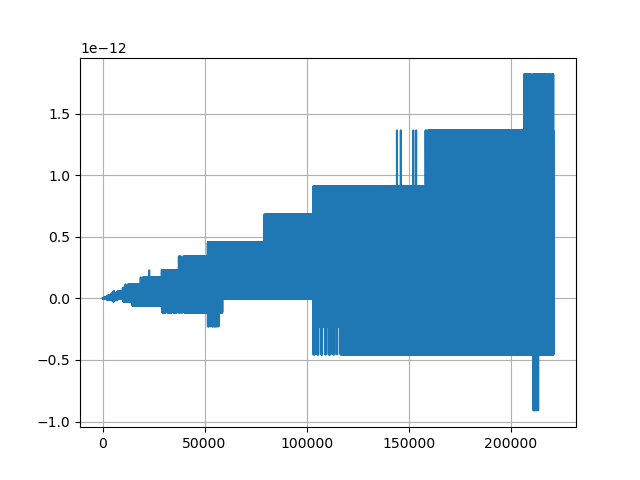

In [ ]:
# print(df["tool_orientation"])
print(df["tool_orientation"].to_numpy())

angle_raw = -df["tool_orientation"].to_numpy()
print(json.dumps(params, indent= 4))


# # -------------------------
# # Global config
# # -------------------------
# DT = 1e-4
# SAMPLES_PER_PERIOD = 360 
# PRINT_EVERY_N = 2000
# SAVE_EXPERIMENT_DATA = True


# # Process settings
# AXIAL_CUTTING_DEPTH_MM = 1.0
# FEED_SPEED_MM_S = 40.0
# SPINDLE_SPIN = -1
# Z_TEETH = 1


# # ----- derived parameters -----
# rotation_period_s = DT * SAMPLES_PER_PERIOD
# frequency_hz = 1.0 / max(rotation_period_s, 1e-12)
# rpm = 60.0 * frequency_hz
# rev_per_s = rpm / 60.0
# omega = SPINDLE_SPIN * 2.0 * np.pi * rev_per_s
# feed_per_tooth_mm = FEED_SPEED_MM_S / max(rev_per_s * Z_TEETH, 1e-12)


d_alpha = np.pi *2 / 360.0
angle_exp = np.zeros(len(angle_raw))

for i in range(0, len(angle_raw)):
     angle_exp[i] = i * d_alpha


diff = angle_exp - angle_raw

plt.figure()
plt.plot(diff)


plt.grid(True)
plt.show()

